In [ ]:
!pip install pyshark --quiet

In [ ]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as f
from pyspark.sql.functions import year,month,to_date,col,round as spark_round


### Combined Data Loading and Transformation

This cell initializes the Spark session, loads the `large_sales_data.csv` into `df_bronze`, and then performs the transformations to create `df_silver`. This ensures that all necessary components are defined sequentially in a single block, avoiding `NameError` issues.

In [ ]:
spark = SparkSession.builder \
    .appName('large_sales_data.csv') \
    .config('spark.sql.adaptive.enabled','true') \
    .getOrCreate()
print(f'Spark version:{spark.version}')

df_bronze = spark.read \
   .option('header','true') \
   .option('inferSchema','true') \
   .csv('large_sales_data.csv')

print('\n=== BRONZE LAYER - RAW Data ===')
print(f'Rows   :   {df_bronze.count()}')
print(f'Columns:   {len(df_bronze.columns)}')
print('\nFirst 5 rows:')
df_bronze.show(5, truncate=False)
print('\nBasic statistics for numeric column:')
df_bronze.select('quantity','unit_price','revenue').describe().show()

df_silver = df_bronze \
    .dropDuplicates() \
    .dropna(subset=['order_id','product','revenue'])
df_silver = df_silver.withColumn(
      'order_date',
      to_date(col('order_date'),'yyyy-MM-dd')
)
df_silver = df_silver \
    .withColumn('order_year', year(col('order_date'))) \
    .withColumn('order_month', month(col('order_date')))
df_silver = df_silver.withColumn(
    'revenue_category',
    f.when(col('revenue') > 4000,'High')\
    .when(col('revenue') > 1000,'Medium')\
    .otherwise('Low')
)

print('\n=== SILVER LAYER - Cleaned Data ===')
print(f'Rows   :   {df_silver.count()}')
print(f'Columns:   {len(df_silver.columns)}')
df_silver.show(5, truncate=False)

Spark version:4.0.2

=== BRONZE LAYER - RAW Data ===
Rows   :   5000
Columns:   13

First 5 rows:
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Ta

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


In [ ]:
spark = SparkSession.builder \
    .appName('large_sales_data.csv') \
    .config('spark.sql.adaptive.enabled','true') \
    .getOrCreate()
print(f'Spark version:{spark.version}')

Spark version:4.0.2


In [ ]:
print('spark version:' ,spark.version)
print('sparkSessions : ACTIVE')
print('Application:',spark.sparkContext.appName)

spark version: 4.0.2
sparkSessions : ACTIVE
Application: large_sales_data.csv


In [ ]:
df_bronze = spark.read \
   .option('header','true') \
   .option('inferSchema','true') \
   .csv('large_sales_data.csv')

print('=== BRONZE LAYER - RAW Data ===')
print(f'Rows   :   {df_bronze.count()}')
print(f'Columns:   {len(df_bronze.columns)}')
print(f'')
print('First 5 rows:')
df_bronze.show(5, truncate=False)
print('\nBasic statistics for numeric column:')
df_bronze.select('quantity','unit_price','revenue').describe().show()

=== BRONZE LAYER - RAW Data ===
Rows   :   5000
Columns:   13

First 5 rows:
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Tablet    |Electronics|

In [ ]:
df_bronze.write \
      .mode('overwrite') \
      .parquet('sales_bronze.parquet')


print('Bronze Parquet saved:sales_bronze.parquet')


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as f
from pyspark.sql.functions import year,month,to_date,col,round as spark_round

try:
    spark
except NameError:
    spark = SparkSession.builder \
        .appName('large_sales_data.csv') \
        .config('spark.sql.adaptive.enabled','true') \
        .getOrCreate()

try:
    df_bronze
except NameError:
    df_bronze = spark.read \
       .option('header','true') \
       .option('inferSchema','true') \
       .csv('large_sales_data.csv')

df_silver = df_bronze \
    .dropDuplicates() \
    .dropna(subset=['order_id','product','revenue'])
df_silver = df_silver.withColumn(
      'order_date',
      to_date(col('order_date'),'yyyy-MM-dd')
)
df_silver = df_silver \
    .withColumn('order_year', year(col('order_date'))) \
    .withColumn('order_month', month(col('order_date')))
df_silver = df_silver.withColumn(
    'revenue_category',
    f.when(col('revenue') > 4000,'High')\
    .when(col('revenue') > 1000,'Medium')\
    .otherwise('Low')
)


In [ ]:
print(f'Silver layer rows: {df_silver.count()}')
print('New columns added:order_year,order_month,revenue_category')
df_silver.select('product','revenue','order_year','order_month','revenue_category').show(5, truncate=False)

In [ ]:
import os

def get_dir_size(path):
    """Get total size of a directory in KB."""
    if os.path.isfile(path):
       return os.path.getsize(path) / 1024
    total = 0
    for dirpath,dirnames,filenames in os.walk(path):
        for f in filenames:
          total += os.path.getsize(os.path.join(dirpath,f))
    return total / 1024

df_silver.write \
    .mode('overwrite') \
    .parquet('sales_silver.parquet')

print('Silver Parquet saved:sales_silver.parquet')
print(f'Silver size: {get_dir_size("sales_silver.parquet"):_.2f} KB')
df_verify_read = spark.read.parquet('sales_silver.parquet')
print(f'Read-back rows: {df_verify_read.count()} (should match Silver count)')
df_verify_read.printSchema()

In [ ]:
import os

def get_dir_size(path):
    """Get total size of a directory in KB."""
    if os.path.isfile(path):
       return os.path.getsize(path) / 1024
    total = 0
    for dirpath,dirnames,filenames in os.walk(path):
        for f in filenames:
          total += os.path.getsize(os.path.join(dirpath,f))
    return total / 1024


In [ ]:
top_products = df_silver \
     .groupBy('product') \
     .agg(
         f.sum('revenue').alias('total_revenue'),
         f.count('order_id').alias('num_order'),
         f.avg('revenue').alias('avg_revenue')
     ) \
     .orderBy('total_revenue',ascending=False) \
     .limit(5)

In [ ]:
print('===TOP 5 PRODUCTS BY REVENUE ===')
top_products.show(truncate=False)

In [ ]:
region_revenue = df_silver \
     .groupBy('region') \
     .agg(
         f.sum('revenue').alias('total_revenue'),
         f.count('order_id').alias('total_order'),
         f.countDistinct('customer_name').alias('unique_customer')
     ) \
     .orderBy('total_revenue',ascending=False)

In [ ]:
gold_region = region_revenue
gold_region.write.mode('overwrite').parquet('gold_region.parquet')
print('Gold 1 saved:gold_region.parquet')

gold_products = df_silver \
   .groupBy('product','category') \
   .agg(\
       f.sum('revenue').alias('total_revenue'),\
       f.count('order_id').alias('units_sold'),\
       spark_round(f.avg('quantity'),1).alias('avg_quantity_per_order'),\
       f.max('revenue').alias('large_order')\
   ) \
   .orderBy('total_revenue',ascending=False)

gold_products.write.mode('overwrite').parquet('gold_product.parquet')
print('Gold 3 saved')

In [ ]:
monthly_trend = df_silver \
    .groupBy('order_month') \
    .agg(f.sum('revenue').alias('monthly_revenue'),
         f.count('order_id').alias('monthly_orders')) \
         .orderBy('order_month')
monthly_trend.write.mode('overwrite').parquet('gold_monthly_trend.parquet')
print('Gold monthly trend saved: gold_monthly_trend.parquet')

Gold monthly trend saved: gold_monthly_trend.parquet


In [ ]:
region_pd = spark.read.parquet('gold_region.parquet').toPandas()
product_pd = spark.read.parquet('gold_product.parquet').toPandas()
monthly_pd = spark.read.parquet('gold_monthly_trend.parquet').toPandas()
print(f'Gold tables converted to Pandas:')
print(f'  Region Revenue: {region_pd.shape}')
print(f'  Product : {product_pd.shape}')
print(f'  Monthly Trend: {monthly_pd.shape}')

region_pd = region_pd.sort_values(by='total_revenue',ascending=False)
product_pd = product_pd.sort_values(by='total_revenue',ascending=False)
monthly_pd = monthly_pd.sort_values(by='order_month')

Gold tables converted to Pandas:
  Region Revenue: (4, 4)
  Product : (10, 6)
  Monthly Trend: (12, 3)


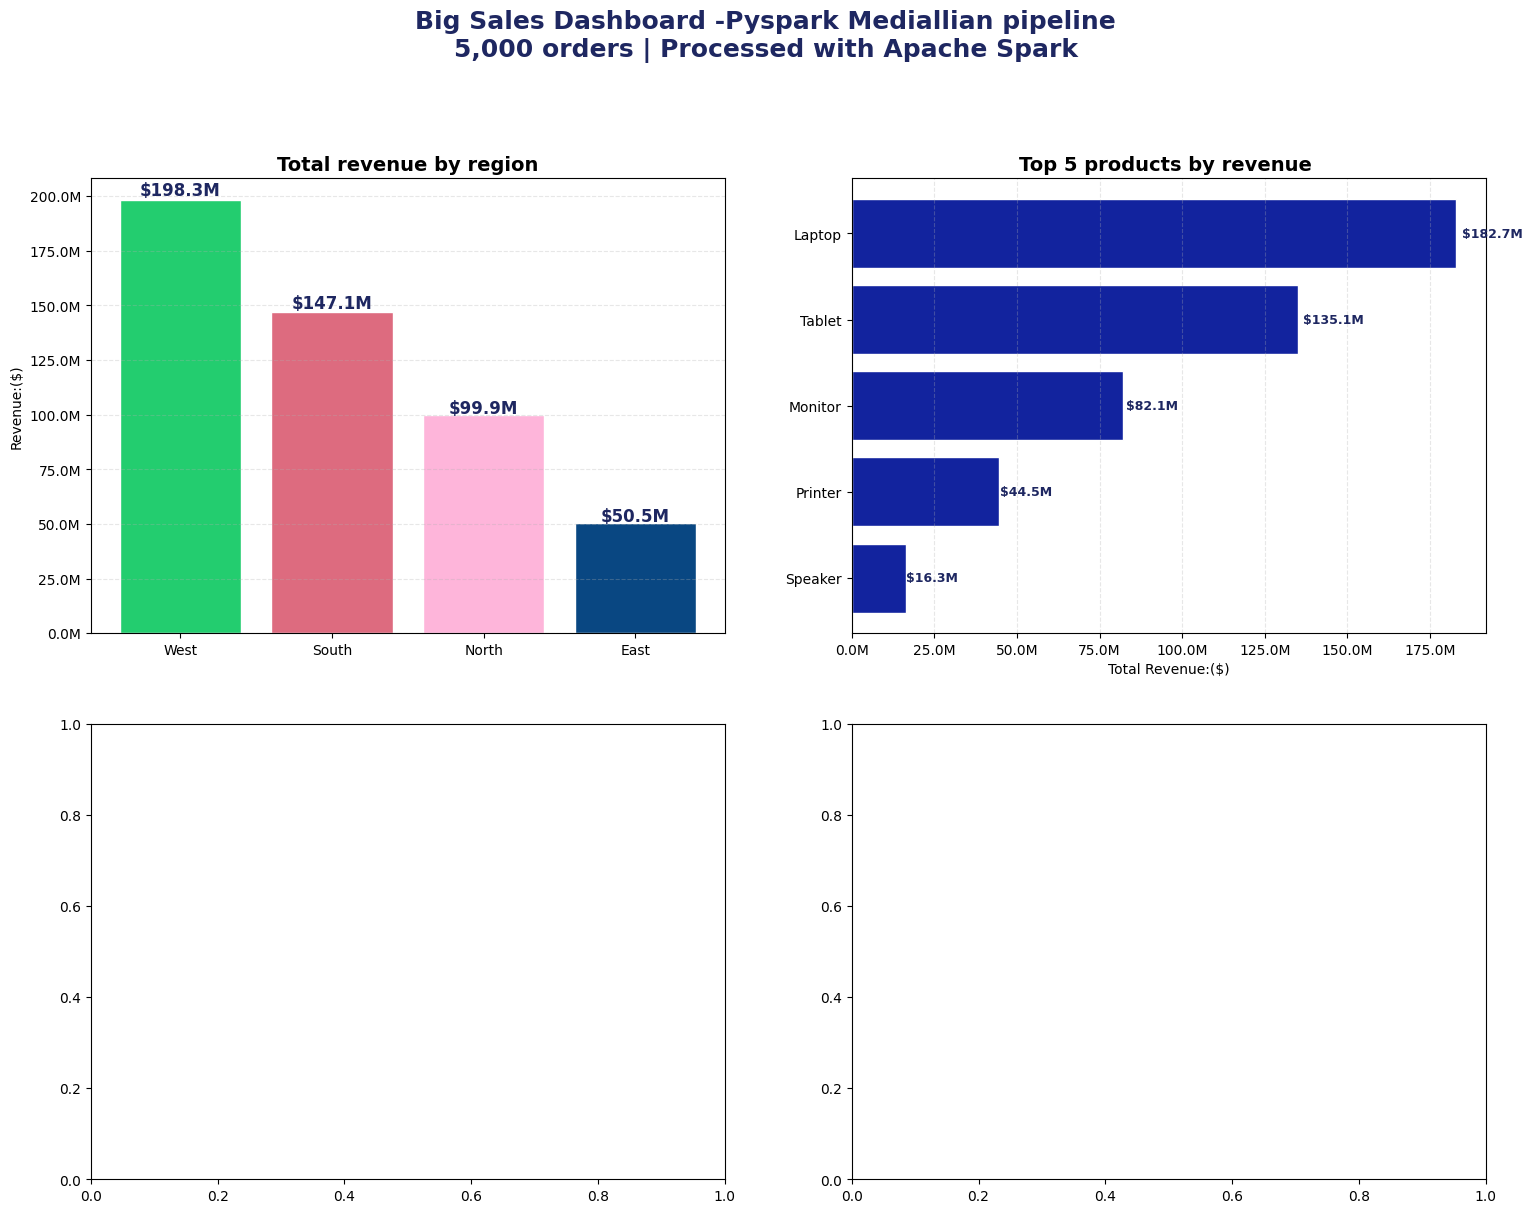

In [ ]:
#Build the Big Sales Dashboard
import matplotlib.pyplot as plt
fig,axes=plt.subplots(2,2,figsize=(18,13))
fig.suptitle("Big Sales Dashboard -Pyspark Mediallian pipeline\n"
                        '5,000 orders | Processed with Apache Spark',
                        fontsize=18,fontweight='bold',color='#1E2761',y=1.01)
colors4=['#23CD6F','#DD6B7F','#FEB5DA','#094782']

ax1=axes[0][0]
bars1=ax1.bar(region_pd['region'],region_pd['total_revenue'],
                color=colors4[:len(region_pd)],edgecolor='white')

for bars in bars1:
    ax1.text(bars.get_x()+bars.get_width()/2,bars.get_height()*1.01,
                f'${bars.get_height()/1e6:.1f}M',
                ha='center',fontweight='bold',fontsize=12,color='#1E2761')
ax1.set_title("Total revenue by region",fontsize=14,fontweight='bold')
ax1.set_ylabel("Revenue:($)")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_y:f'{x/1e6:.1f}M'))
ax1.grid(axis='y',alpha=0.3,linestyle='--')


ax2=axes[0][1]
top5_prod=product_pd.head(5).sort_values('total_revenue')
bars2=ax2.barh(top5_prod['product'],top5_prod['total_revenue'],
                color='#12239E',edgecolor='white')
for bars in bars2:
    ax2.text(bars.get_width()*1.01,bars.get_y()+bars.get_height()/2,
                f'${bars.get_width()/1e6:.1f}M',
                va='center',fontweight='bold',fontsize=9,color='#1E2761')
ax2.set_title("Top 5 products by revenue ",fontsize=14,fontweight='bold')
ax2.set_xlabel("Total Revenue:($)")
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_y:f'{x/1e6:.1f}M'))
ax2.grid(axis='x',alpha=0.3,linestyle='--')


In [ ]:
#cell 18
print('=== Activity 2: file format comparsion ===')
print()
csv_kb     = get_dir_size('large_sales_data.csv')
bronze_kb  = get_dir_size('sales_bronze.parquet')
silver_kb  = get_dir_size('sales_silver.parquet')
gold_kb    = (get_dir_size('gold_region.parquet') +
              get_dir_size('gold_product.parquet') +
              get_dir_size('gold_monthly_trend.parquet'))
print(f"{'File':<38} {'Size (KB)':>10} {'vs CSV':>10}")
print(f"{'large_sales_data.csv':<38} {csv_kb:>10.2f} {100.0:>9.1f}%")
print(f"{'sales_bronze.parquet':<38} {bronze_kb:>10.2f} {bronze_kb/csv_kb*100:>9.1f}%")
print(f"{'sales_silver.parquet':<38} {silver_kb:>10.2f} {silver_kb/csv_kb*100:>9.1f}%")
print(f"{'gold_*.parquet':<38} {gold_kb:>10.2f} {gold_kb/csv_kb*100:>9.1f}%")

=== Activity 2: file format comparsion ===

File                                    Size (KB)     vs CSV


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

dt_model = DecisionTreeRegressor(
     max_depth=5,
     random_state=42
)

